# Olist Brazilian E-Commerce — SQL + Python Analysis

This notebook extends a SQL-based business analysis of the [Olist Brazilian E-Commerce dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) into Python, using `pandas` to run the same validated SQL queries against a SQLite database and `matplotlib`/`seaborn` to visualize the results.

**Business questions answered:**
1. Which product categories generate the most revenue, and how has revenue trended month over month?
2. Who are the top sellers by revenue, and how does order volume relate to revenue?
3. Do best-selling products also have the best review scores?

**Tools:** SQLite, `pandas`, `matplotlib`, `seaborn`


## Setup

Connect to the SQLite database (`olist_ecommerce.db`, built from the raw Olist CSVs). Make sure this file is in the same folder as this notebook, or update the path below.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

conn = sqlite3.connect(r"olist_ecommerce.db")

## Explore the database

Quick check that the connection works and all expected tables are present.

In [2]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                   name
0                orders
1           geolocation
2           order_items
3              payments
4              products
5               sellers
6               reviews
7  category_translation
8             customers


## Question 1a: Top 10 Product Categories by Revenue

Revenue is calculated as the sum of item `price` (excluding freight) across `order_items`, joined to `products` and `category_translation` to get readable English category names.

In [3]:
top_categories = pd.read_sql("""
    SELECT 
        ct.product_category_name_english,
        SUM(oi.price) AS total_revenue
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    GROUP BY product_category_name_english
    ORDER BY total_revenue DESC
    LIMIT 10;
""", conn)

top_categories

,product_category_name_english,total_revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


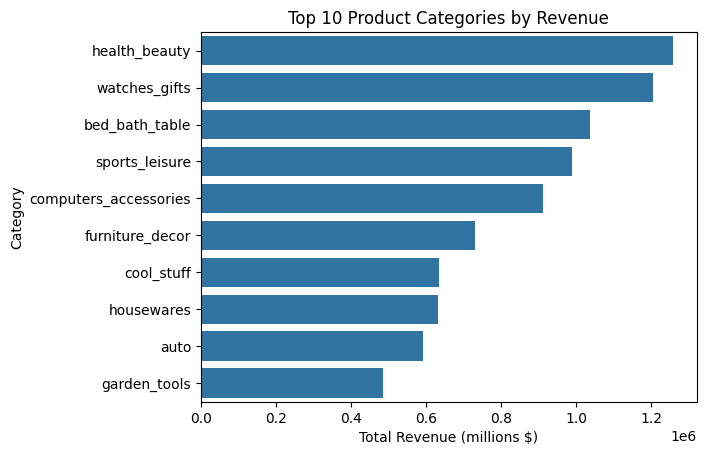

In [8]:

sns.barplot(data=top_categories, x="total_revenue", y="product_category_name_english")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue (millions $)")
plt.ylabel("Category")
plt.show()

**Finding:** `health_beauty` leads in total revenue (~R$1.26M), followed closely by `watches_gifts` (~R$1.21M). Notably, `watches_gifts` ranks #2 despite likely lower order volume than some categories below it — suggesting a higher average price per item rather than higher sales volume.

## Question 1b: Monthly Revenue Trend

Revenue grouped by year-month using `order_approved_at`, to see how the platform's revenue grew over time.

In [9]:
monthly_revenue = pd.read_sql("""
    SELECT 
        strftime('%Y-%m', order_approved_at) AS timeOfOrder,
        SUM(oi.price) AS total_revenue
    FROM orders o
    JOIN order_items oi ON oi.order_id = o.order_id
    GROUP BY timeOfOrder
    ORDER BY timeOfOrder;
""", conn)

monthly_revenue

,timeOfOrder,total_revenue
0,None,1670.43
1,2016-09,134.97
2,2016-10,49640.05
3,2016-12,10.90
4,2017-01,114860.71
5,2017-02,247441.08
6,2017-03,370611.56
7,2017-04,357638.73
8,2017-05,507167.89
9,2017-06,437278.58


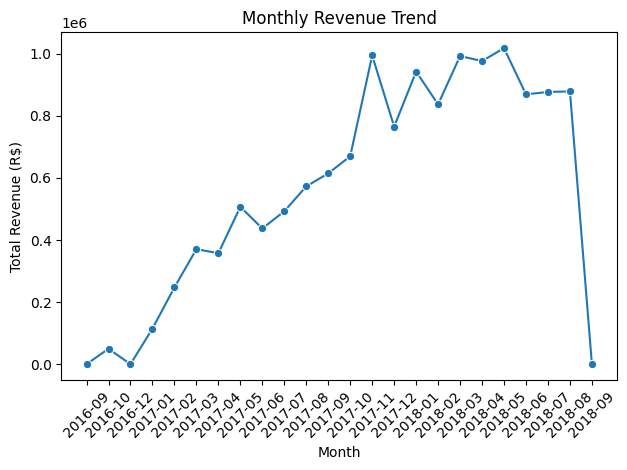

In [11]:

sns.lineplot(data=monthly_revenue.dropna(), x="timeOfOrder", y="total_revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** Revenue is minimal through late 2016 (platform ramp-up), then grows steadily throughout 2017, peaking in November 2017 — most likely a Black Friday effect. 2018 revenue stays strong but plateaus relative to that peak. The final month in the dataset shows an apparent sharp drop, which reflects **incomplete data** (the dataset was extracted mid-month) rather than an actual decline — worth noting explicitly rather than misreading it as a business downturn.

## Question 2: Top 10 Sellers by Revenue

Total revenue and order volume per seller, to see whether top earners rely on high sales volume or high-value items.

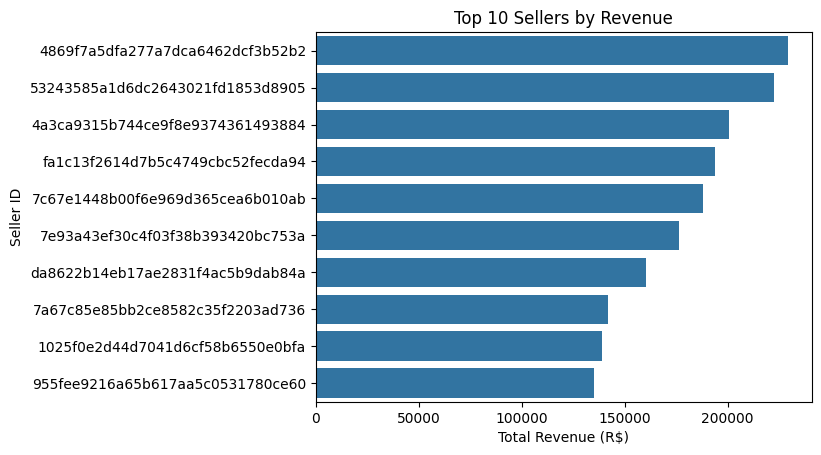

In [13]:
top_sellers = pd.read_sql("""
    SELECT 
        s.seller_id, 
        SUM(oi.price) AS revenue, 
        COUNT(*) AS numberOfOrders
    FROM order_items oi 
    JOIN sellers s ON s.seller_id = oi.seller_id
    GROUP BY s.seller_id
    ORDER BY revenue DESC
    LIMIT 10;
""", conn)

sns.barplot(data=top_sellers, x="revenue", y="seller_id")
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Seller ID")
plt.show()

**Finding:** The top 10 sellers show a fairly gradual revenue drop-off rather than one dominant seller. More interestingly, they get there through different strategies — e.g. one top seller has ~1,987 orders averaging ~$101/item, while another reaches similar revenue with only ~340 orders averaging ~$519/item. High revenue can come from either high volume or high price point.

## Question 3: Best-Selling Products vs. Review Scores

Do the top 20 best-selling products (by units sold) also have the best average review scores?

**Data quality note:** a small number of orders had more than one review row attached in the raw data. To avoid inflating unit-sold counts, review scores are pre-aggregated to one row per `order_id` (via a subquery) before joining, so each order — and therefore each product — is only counted once.

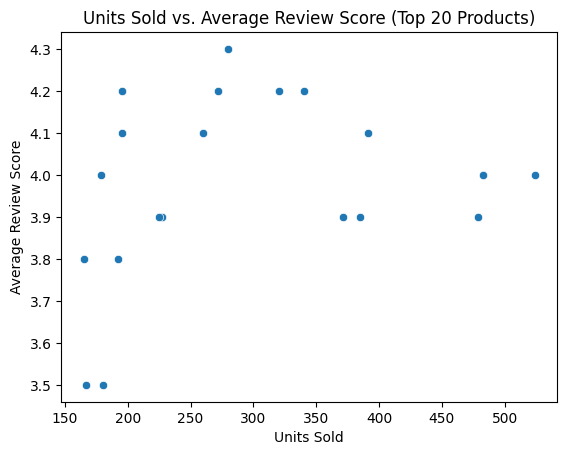

In [15]:
product_reviews = pd.read_sql("""
    SELECT 
        oi.product_id, 
        COUNT(oi.order_id) AS unitSold, 
        ROUND(AVG(rev.avg_score), 1) AS reviewsScore
    FROM order_items oi
    JOIN products p ON p.product_id = oi.product_id
    JOIN orders o ON o.order_id = oi.order_id
    JOIN (
        SELECT order_id, AVG(review_score) AS avg_score
        FROM reviews
        GROUP BY order_id
    ) rev ON rev.order_id = o.order_id
    GROUP BY p.product_id
    ORDER BY unitSold DESC
    LIMIT 20;
""", conn)

sns.scatterplot(data=product_reviews, x="unitSold", y="reviewsScore")
plt.title("Units Sold vs. Average Review Score (Top 20 Products)")
plt.xlabel("Units Sold")
plt.ylabel("Average Review Score")
plt.show()

**Finding:** Review scores stay fairly consistent (mostly in the 3.5–4.5 range) across the top 20 best-selling products regardless of units sold — there's no strong relationship between how much a product sells and how well it's reviewed. This suggests sales volume is likely driven more by price, visibility, or category demand than by customer satisfaction alone.

## Summary

- **Revenue** is concentrated in health & beauty, gifts/watches, and home categories, with steady platform growth through 2017 and a clear Black Friday spike in November 2017.
- **Sellers** reach the top 10 by revenue through different strategies — high order volume vs. high price per item — rather than one single winning approach.
- **Product reviews** are not meaningfully correlated with sales volume in this dataset; best-sellers aren't necessarily the best-reviewed products.

This notebook builds on a separate SQL-only analysis (`queries.sql`) of the same dataset, using `pd.read_sql()` to run the same validated queries directly from Python and add visualizations.